# 03 — Eksperimen Feature Selection (FS0–FS3)

**Judul Penelitian:** Eksperimen Klasifikasi Depresi pada Remaja: Perbandingan Metode Feature Selection untuk Identifikasi Fitur Gaya Hidup Paling Berpengaruh

**Tujuan notebook ini:**
- Membandingkan empat skenario feature selection (**FS0–FS3**) dengan klasifikator tetap **Random Forest**
- Menjawab **RQ1** (performa terbaik) dan **RQ3** (karakteristik metode)
- Mengidentifikasi fitur gaya hidup paling berpengaruh (**RQ2**) dari Chi-Square dan Mutual Information
- Menyiapkan model terbaik untuk analisis SHAP di notebook `04_xai_shap_analysis.ipynb` (**RQ4**)

| Kode | Metode | Data Input |
|------|--------|------------|
| FS0 | Tanpa seleksi (baseline) | `train_scaled` |
| FS1 | PCA (≥95% variansi) | `train_scaled` |
| FS2 | Chi-Square `SelectKBest(chi2, k)` | `train_minmax` |
| FS3 | Mutual Information `SelectKBest(mutual_info_classif, k)` | `train_scaled` |

**Desain eksperimen (proposal §4.3):**
- Klasifikator tetap: `RandomForest(n_estimators=100, class_weight='balanced')`
- Validasi: Stratified **5-Fold CV** pada data latih
- Evaluasi final: hold-out test set (300 sampel)
- Tuning *k* untuk FS2 & FS3: k ∈ {5, 8, 10}
- Metrik utama: **F1-Score**, **Recall**, **ROC-AUC**

In [19]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
CV_FOLDS = 5
K_CANDIDATES = [5, 8, 10]
PCA_VARIANCE = 0.95
RF_PARAMS = dict(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'

for d in [FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

with open(ARTIFACTS_DIR / 'preprocessing_metadata.json', encoding='utf-8') as f:
    meta = json.load(f)

TARGET_COL = meta['target_col']
FEATURE_COLS = meta['feature_cols']
print(f'Fitur: {len(FEATURE_COLS)}, Train/Test dari preprocessing notebook 02')

Fitur: 14, Train/Test dari preprocessing notebook 02


In [20]:
train_scaled = pd.read_csv(PROCESSED_DIR / 'train_scaled.csv')
test_scaled = pd.read_csv(PROCESSED_DIR / 'test_scaled.csv')
train_minmax = pd.read_csv(PROCESSED_DIR / 'train_minmax.csv')
test_minmax = pd.read_csv(PROCESSED_DIR / 'test_minmax.csv')

X_train_s = train_scaled[FEATURE_COLS]
y_train = train_scaled[TARGET_COL]
X_test_s = test_scaled[FEATURE_COLS]
y_test = test_scaled[TARGET_COL]
X_train_m = train_minmax[FEATURE_COLS]
X_test_m = test_minmax[FEATURE_COLS]

print('Train:', X_train_s.shape, '| Test:', X_test_s.shape)
print('Distribusi kelas (train):', y_train.value_counts().to_dict())

Train: (1200, 14) | Test: (300, 14)
Distribusi kelas (train): {0: 1080, 1: 120}


## 1. Fungsi Evaluasi & Pipeline

Feature selection diintegrasikan dalam `sklearn.pipeline.Pipeline` agar seleksi fitur hanya dilakukan pada fold latih saat cross-validation (mencegah data leakage).

In [21]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}


def run_cv(pipeline, X, y):
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)
    return {m: scores[f'test_{m}'].mean() for m in scoring}


def eval_test(pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'pipeline': pipeline,
    }

## 2. Tuning k untuk Chi-Square (FS2) dan Mutual Information (FS3)

Sesuai proposal §4.3, nilai *k* = 5, 8, 10 diuji menggunakan 5-Fold CV. *k* dengan F1-Score CV tertinggi dipilih untuk eksperimen utama.

In [22]:
k_tuning_rows = []
best_k_chi2, best_k_mi = 8, 8
best_f1_chi2, best_f1_mi = -1, -1

for k in K_CANDIDATES:
    pipe_chi2 = Pipeline([
        ('select', SelectKBest(chi2, k=k)),
        ('clf', RandomForestClassifier(**RF_PARAMS)),
    ])
    pipe_mi = Pipeline([
        ('select', SelectKBest(mutual_info_classif, k=k)),
        ('clf', RandomForestClassifier(**RF_PARAMS)),
    ])
    cv_chi2 = run_cv(pipe_chi2, X_train_m, y_train)
    cv_mi = run_cv(pipe_mi, X_train_s, y_train)
    k_tuning_rows.append({'metode': 'Chi-Square', 'k': k, **{f'cv_{m}': round(v, 4) for m, v in cv_chi2.items()}})
    k_tuning_rows.append({'metode': 'Mutual Information', 'k': k, **{f'cv_{m}': round(v, 4) for m, v in cv_mi.items()}})
    if cv_chi2['f1'] > best_f1_chi2:
        best_f1_chi2, best_k_chi2 = cv_chi2['f1'], k
    if cv_mi['f1'] > best_f1_mi:
        best_f1_mi, best_k_mi = cv_mi['f1'], k

k_tuning_df = pd.DataFrame(k_tuning_rows)
k_tuning_df.to_csv(TABLES_DIR / '10_k_tuning_chi2_mi.csv', index=False)
print(f'k optimal — Chi-Square: {best_k_chi2}, Mutual Information: {best_k_mi}')
k_tuning_df

k optimal — Chi-Square: 8, Mutual Information: 5


,metode,k,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
0,Chi-Square,5,0.9925,0.9746,0.9500,0.9619,0.9990
1,Mutual Information,5,0.9917,0.9743,0.9417,0.9574,0.9980
2,Chi-Square,8,0.9942,0.9913,0.9500,0.9698,0.9993
3,Mutual Information,8,0.9892,0.9735,0.9167,0.9437,0.9990
4,Chi-Square,10,0.9933,0.9826,0.9500,0.9660,0.9990
5,Mutual Information,10,0.9900,0.9735,0.9250,0.9484,0.9991


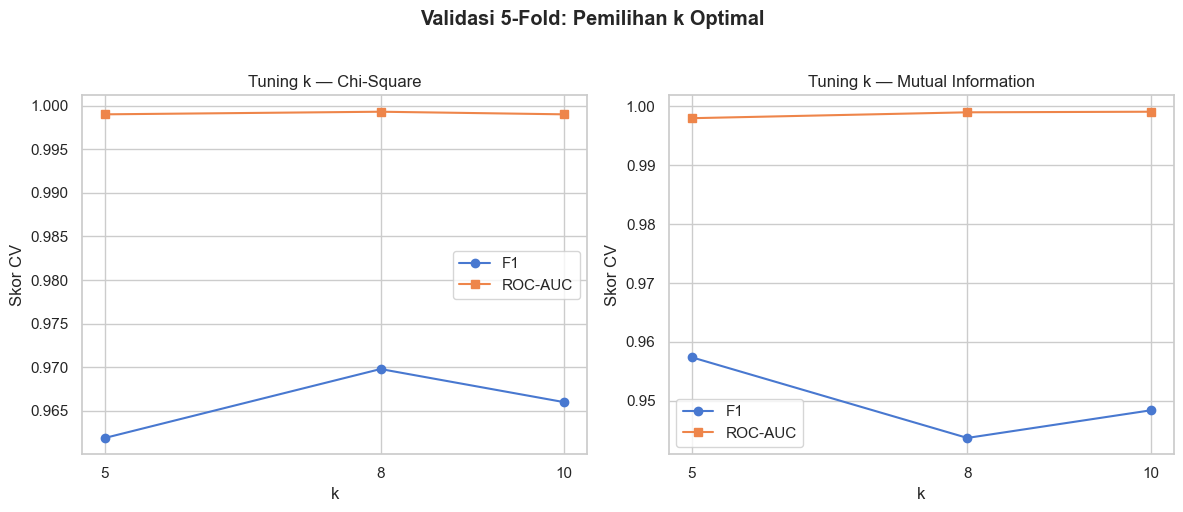

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['Chi-Square', 'Mutual Information']):
    sub = k_tuning_df[k_tuning_df['metode'] == col]
    ax.plot(sub['k'], sub['cv_f1'], marker='o', label='F1')
    ax.plot(sub['k'], sub['cv_roc_auc'], marker='s', label='ROC-AUC')
    ax.set_title(f'Tuning k — {col}')
    ax.set_xlabel('k'); ax.set_ylabel('Skor CV'); ax.set_xticks(K_CANDIDATES); ax.legend()
plt.suptitle('Validasi 5-Fold: Pemilihan k Optimal', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_k_tuning.png', bbox_inches='tight')
plt.show()

## 3. Penentuan Komponen PCA (FS1)

Jumlah komponen utama ditentukan agar **cumulative explained variance ≥ 95%** (proposal §4.3).

In [24]:
pca_probe = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
pca_probe.fit(X_train_s)
n_pca = pca_probe.n_components_
explained = pca_probe.explained_variance_ratio_
cumvar = np.cumsum(explained)

pca_info = pd.DataFrame({
    'komponen': [f'PC{i+1}' for i in range(len(explained))],
    'explained_variance_ratio': explained.round(4),
    'cumulative_variance': cumvar.round(4),
})
pca_info.to_csv(TABLES_DIR / '14_pca_components.csv', index=False)
print(f'Jumlah komponen PCA: {n_pca}')
pca_info

Jumlah komponen PCA: 12


,komponen,explained_variance_ratio,cumulative_variance
0,PC1,0.1436,0.1436
1,PC2,0.1095,0.2531
2,PC3,0.0926,0.3457
3,PC4,0.0784,0.4241
4,PC5,0.0757,0.4999
5,PC6,0.0750,0.5748
6,PC7,0.0723,0.6471
7,PC8,0.0673,0.7144
8,PC9,0.0651,0.7795
9,PC10,0.0625,0.8420


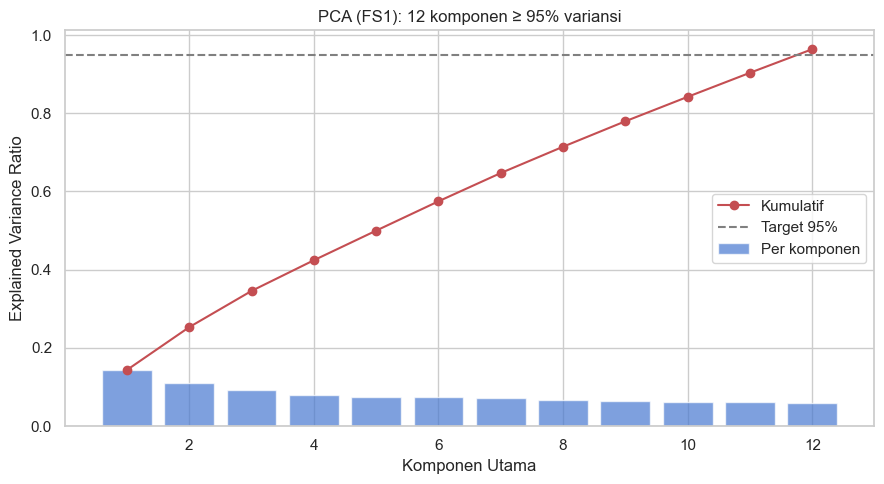

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.7, label='Per komponen')
ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#C44E52', label='Kumulatif')
ax.axhline(PCA_VARIANCE, ls='--', color='gray', label=f'Target {PCA_VARIANCE:.0%}')
ax.set_xlabel('Komponen Utama'); ax.set_ylabel('Explained Variance Ratio')
ax.set_title(f'PCA (FS1): {n_pca} komponen ≥ {PCA_VARIANCE:.0%} variansi'); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_pca_explained_variance.png', bbox_inches='tight')
plt.show()

## 4. Eksperimen Utama — Perbandingan FS0–FS3 (RQ1, RQ3)

Setiap skenario dievaluasi dengan 5-Fold CV pada data latih, lalu model final dilatih pada seluruh data latih dan diuji pada hold-out test set.

In [26]:
scenarios = {
    'FS0': {
        'label': 'Tanpa Seleksi (Baseline)',
        'pipeline': Pipeline([('clf', RandomForestClassifier(**RF_PARAMS))]),
        'X_train': X_train_s, 'X_test': X_test_s,
        'feature_info': f'Semua {len(FEATURE_COLS)} fitur',
    },
    'FS1': {
        'label': 'PCA (>=95% variansi)',
        'pipeline': Pipeline([
            ('pca', PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)),
            ('clf', RandomForestClassifier(**RF_PARAMS)),
        ]),
        'X_train': X_train_s, 'X_test': X_test_s,
        'feature_info': f'{n_pca} komponen utama',
    },
    'FS2': {
        'label': f'Chi-Square (k={best_k_chi2})',
        'pipeline': Pipeline([
            ('select', SelectKBest(chi2, k=best_k_chi2)),
            ('clf', RandomForestClassifier(**RF_PARAMS)),
        ]),
        'X_train': X_train_m, 'X_test': X_test_m,
        'feature_info': f'Top-{best_k_chi2} fitur Chi-Square',
    },
    'FS3': {
        'label': f'Mutual Information (k={best_k_mi})',
        'pipeline': Pipeline([
            ('select', SelectKBest(mutual_info_classif, k=best_k_mi)),
            ('clf', RandomForestClassifier(**RF_PARAMS)),
        ]),
        'X_train': X_train_s, 'X_test': X_test_s,
        'feature_info': f'Top-{best_k_mi} fitur MI',
    },
}

cv_rows, test_rows, fitted_models = [], [], {}
for code_id, cfg in scenarios.items():
    cv_res = run_cv(cfg['pipeline'], cfg['X_train'], y_train)
    test_res = eval_test(cfg['pipeline'], cfg['X_train'], y_train, cfg['X_test'], y_test)
    fitted_models[code_id] = test_res['pipeline']
    cv_rows.append({'skenario': code_id, 'metode': cfg['label'], 'fitur': cfg['feature_info'],
                    **{f'cv_{k}': round(v, 4) for k, v in cv_res.items()}})
    test_rows.append({'skenario': code_id, 'metode': cfg['label'], 'fitur': cfg['feature_info'],
                      'accuracy': round(test_res['accuracy'], 4), 'precision': round(test_res['precision'], 4),
                      'recall': round(test_res['recall'], 4), 'f1': round(test_res['f1'], 4),
                      'roc_auc': round(test_res['roc_auc'], 4),
                      'y_pred': test_res['y_pred'], 'y_proba': test_res['y_proba']})

cv_df = pd.DataFrame(cv_rows)
test_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('y_pred', 'y_proba')} for r in test_rows])
cv_df.to_csv(TABLES_DIR / '11_cv_results_fs_comparison.csv', index=False)
test_df.to_csv(TABLES_DIR / '12_test_results_fs_comparison.csv', index=False)
test_df

,skenario,metode,fitur,accuracy,precision,recall,f1,roc_auc
0,FS0,Tanpa Seleksi (Baseline),Semua 14 fitur,0.9833,1.0000,0.8333,0.9091,0.9970
1,FS1,PCA (>=95% variansi),12 komponen utama,0.9467,0.8889,0.5333,0.6667,0.9644
2,FS2,Chi-Square (k=8),Top-8 fitur Chi-Square,0.9967,1.0000,0.9667,0.9831,0.9980
3,FS3,Mutual Information (k=5),Top-5 fitur MI,0.9967,1.0000,0.9667,0.9831,0.9987


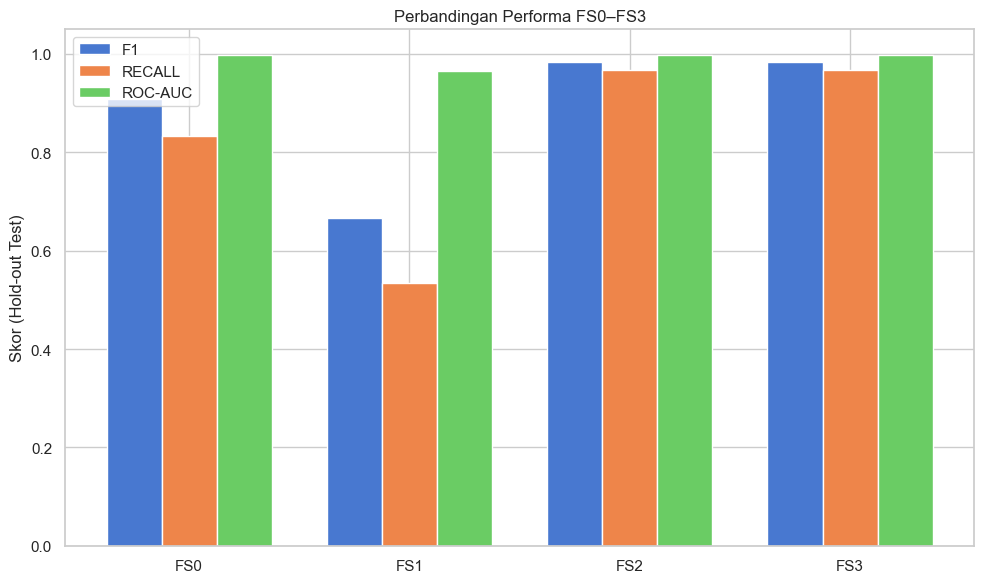

In [27]:
metrics_plot = ['f1', 'recall', 'roc_auc']
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(scenarios)); w = 0.25
for i, m in enumerate(metrics_plot):
    ax.bar(x + i*w, test_df[m], w, label=m.upper().replace('_', '-'))
ax.set_xticks(x + w); ax.set_xticklabels(list(scenarios.keys()))
ax.set_ylabel('Skor (Hold-out Test)'); ax.set_title('Perbandingan Performa FS0–FS3')
ax.legend(); ax.set_ylim(0, 1.05); plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_fs_comparison_metrics.png', bbox_inches='tight')
plt.show()

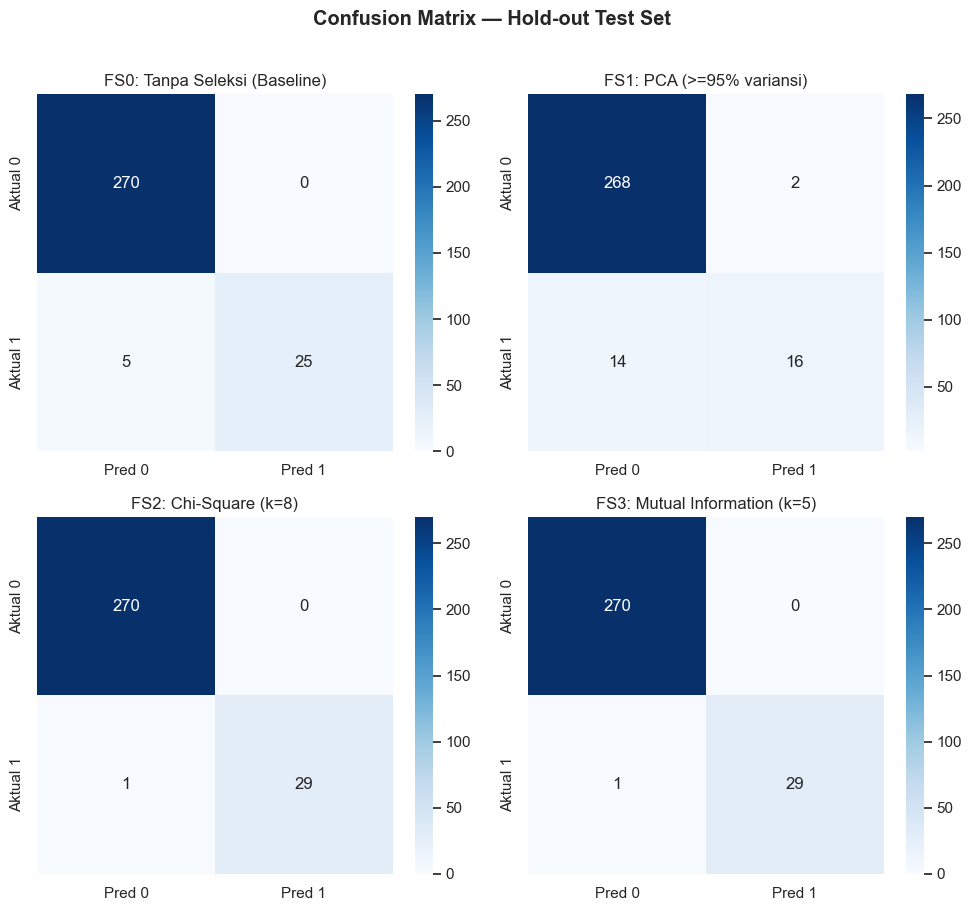

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, row in zip(axes.ravel(), test_rows):
    cm = confusion_matrix(y_test, row['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['Aktual 0','Aktual 1'])
    ax.set_title(f"{row['skenario']}: {row['metode']}")
plt.suptitle('Confusion Matrix — Hold-out Test Set', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_confusion_matrices.png', bbox_inches='tight')
plt.show()

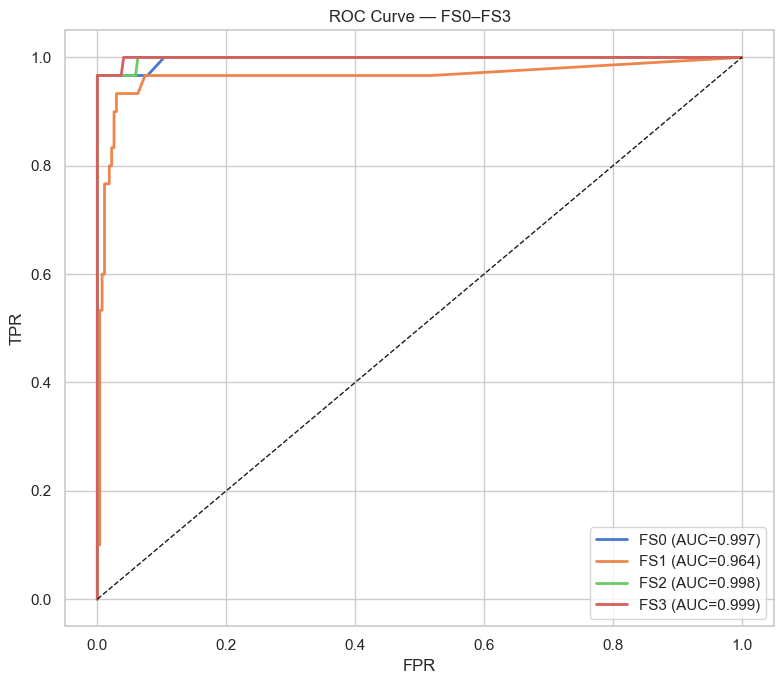

In [29]:
fig, ax = plt.subplots(figsize=(8, 7))
for row in test_rows:
    fpr, tpr, _ = roc_curve(y_test, row['y_proba'])
    ax.plot(fpr, tpr, lw=2, label=f"{row['skenario']} (AUC={row['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curve — FS0–FS3')
ax.legend(loc='lower right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_roc_curves.png', bbox_inches='tight')
plt.show()

## 5. Identifikasi Fitur Paling Berpengaruh (RQ2)

Metode filter (**FS2** Chi-Square dan **FS3** Mutual Information) mempertahankan nama fitur asli, sehingga ranking skor dapat diinterpretasi secara klinis. Hasil dibandingkan silang untuk menemukan fitur yang **konsisten** terpilih.

In [30]:
chi2_selector = SelectKBest(chi2, k=best_k_chi2)
chi2_selector.fit(X_train_m, y_train)
chi2_scores = pd.DataFrame({
    'fitur': FEATURE_COLS, 'chi2_score': chi2_selector.scores_.round(4),
    'terpilih': chi2_selector.get_support(),
}).sort_values('chi2_score', ascending=False)
chi2_scores.to_csv(TABLES_DIR / '13_chi2_feature_ranking.csv', index=False)
chi2_selected = chi2_scores[chi2_scores['terpilih']]['fitur'].tolist()

mi_selector = SelectKBest(mutual_info_classif, k=best_k_mi)
mi_selector.fit(X_train_s, y_train)
mi_scores = pd.DataFrame({
    'fitur': FEATURE_COLS, 'mi_score': mi_selector.scores_.round(4),
    'terpilih': mi_selector.get_support(),
}).sort_values('mi_score', ascending=False)
mi_scores.to_csv(TABLES_DIR / '13_mi_feature_ranking.csv', index=False)
mi_selected = mi_scores[mi_scores['terpilih']]['fitur'].tolist()

overlap = sorted(set(chi2_selected) & set(mi_selected))
pd.DataFrame([
    {'kategori': 'Konsisten (FS2 & FS3)', 'fitur': ', '.join(overlap) or '-'},
    {'kategori': 'Hanya Chi-Square', 'fitur': ', '.join(sorted(set(chi2_selected)-set(mi_selected))) or '-'},
    {'kategori': 'Hanya Mutual Information', 'fitur': ', '.join(sorted(set(mi_selected)-set(chi2_selected))) or '-'},
])

,kategori,fitur
0,Konsisten (FS2 & FS3),"anxiety_level, daily_social_media_hours, sleep..."
1,Hanya Chi-Square,"gender, platform_Instagram, platform_TikTok, s..."
2,Hanya Mutual Information,physical_activity


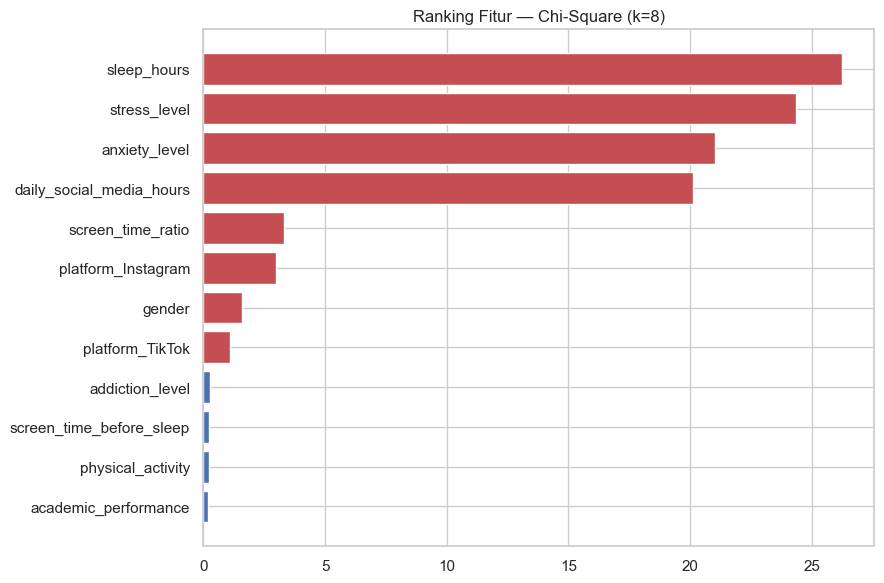

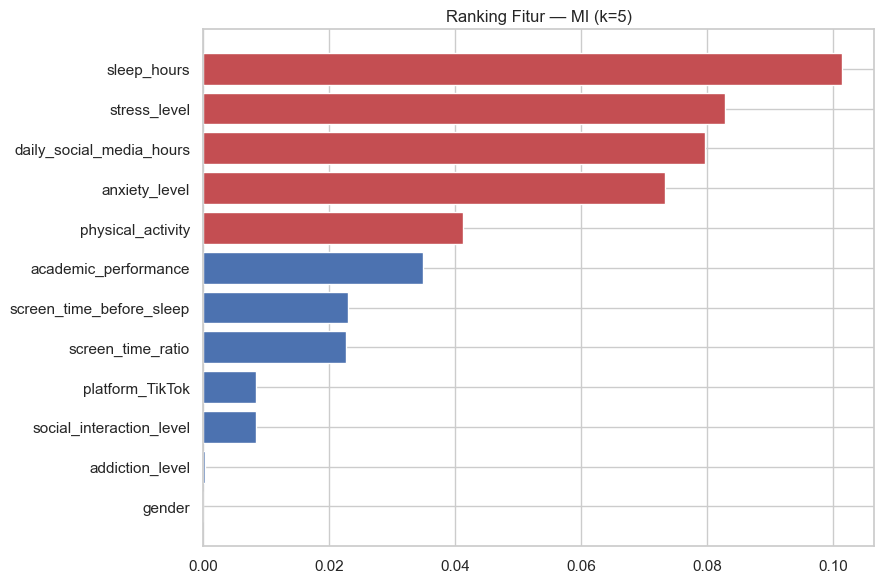

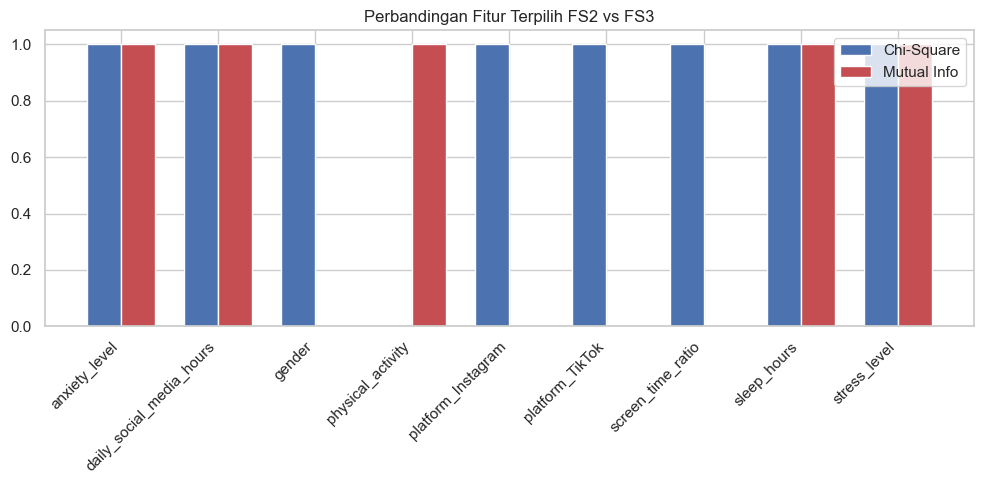

In [31]:
for scores_df, score_col, title, fname in [
    (chi2_scores.head(12), 'chi2_score', f'Ranking Fitur — Chi-Square (k={best_k_chi2})', '16_chi2_feature_ranking.png'),
    (mi_scores.head(12), 'mi_score', f'Ranking Fitur — MI (k={best_k_mi})', '17_mi_feature_ranking.png'),
]:
    fig, ax = plt.subplots(figsize=(9, 6))
    plot_df = scores_df.sort_values(score_col)
    colors = ['#C44E52' if t else '#4C72B0' for t in plot_df['terpilih']]
    ax.barh(plot_df['fitur'], plot_df[score_col], color=colors)
    ax.set_title(title); plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, bbox_inches='tight'); plt.show()

all_feats = sorted(set(chi2_selected) | set(mi_selected))
comp = pd.DataFrame({'fitur': all_feats,
    'chi2': [1 if f in chi2_selected else 0 for f in all_feats],
    'mi': [1 if f in mi_selected else 0 for f in all_feats]})
x = np.arange(len(all_feats)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w/2, comp['chi2'], w, label='Chi-Square', color='#4C72B0')
ax.bar(x+w/2, comp['mi'], w, label='Mutual Info', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(all_feats, rotation=45, ha='right')
ax.set_title('Perbandingan Fitur Terpilih FS2 vs FS3'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / '18_feature_overlap.png', bbox_inches='tight'); plt.show()

## 6. Overfitting Check & Validasi Hipotesis (H1–H4)

Membandingkan skor CV vs hold-out test untuk skenario terbaik, serta merangkum status hipotesis penelitian.

In [32]:
overfit_df = cv_df.merge(test_df[['skenario','f1','roc_auc']], on='skenario')
overfit_df = overfit_df.rename(columns={'f1':'test_f1','roc_auc':'test_roc_auc'})
overfit_df['delta_f1'] = (overfit_df['test_f1'] - overfit_df['cv_f1']).round(4)
overfit_df.to_csv(TABLES_DIR / '16_overfitting_check.csv', index=False)
overfit_df

,skenario,metode,fitur,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,test_f1,test_roc_auc,delta_f1
0,FS0,Tanpa Seleksi (Baseline),Semua 14 fitur,0.9900,0.9913,0.9083,0.9476,0.9994,0.9091,0.9970,-0.0385
1,FS1,PCA (>=95% variansi),12 komponen utama,0.9575,0.9523,0.6083,0.7387,0.9890,0.6667,0.9644,-0.0720
2,FS2,Chi-Square (k=8),Top-8 fitur Chi-Square,0.9942,0.9913,0.9500,0.9698,0.9993,0.9831,0.9980,0.0133
3,FS3,Mutual Information (k=5),Top-5 fitur MI,0.9908,0.9739,0.9333,0.9528,0.9980,0.9831,0.9987,0.0303


In [33]:
best_row = test_df.sort_values(['f1', 'roc_auc'], ascending=False).iloc[0]
best_code = best_row['skenario']
joblib.dump(fitted_models[best_code], ARTIFACTS_DIR / 'best_fs_model.joblib')

fs0_f1 = test_df.loc[test_df['skenario']=='FS0','f1'].values[0]
fs2_f1 = test_df.loc[test_df['skenario']=='FS2','f1'].values[0]
fs3_f1 = test_df.loc[test_df['skenario']=='FS3','f1'].values[0]
best_fs_f1 = test_df[test_df['skenario'].isin(['FS1','FS2','FS3'])]['f1'].max()
lifestyle = {'sleep_hours','stress_level','anxiety_level','physical_activity',
             'daily_social_media_hours','screen_time_before_sleep','screen_time_ratio'}

h1_status = 'Diterima' if fs3_f1 > fs2_f1 else ('Ditolak' if fs3_f1 < fs2_f1 else 'Sebagian (F1 seri)')
hyp_df = pd.DataFrame([
    {'hipotesis':'H1','pernyataan':'MI > Chi-Square pada F1',
     'status': h1_status, 'bukti':f'FS3={fs3_f1:.4f}, FS2={fs2_f1:.4f}'},
    {'hipotesis':'H2','pernyataan':'PCA kehilangan interpretabilitas nama fitur',
     'status':'Diterima', 'bukti':f'{n_pca} komponen (PC1–PC{n_pca}), bukan nama fitur asli'},
    {'hipotesis':'H3','pernyataan':'FS meningkatkan performa vs baseline',
     'status':'Diterima' if best_fs_f1>fs0_f1 else 'Ditolak', 'bukti':f'Baseline={fs0_f1:.4f}, terbaik FS={best_fs_f1:.4f}'},
    {'hipotesis':'H4','pernyataan':'Fitur tidur/stres/kecemasan/aktivitas fisik konsisten terpilih',
     'status':'Diterima' if len(set(overlap)&lifestyle)>=2 else 'Sebagian',
     'bukti':str(sorted(set(overlap)&lifestyle))},
])
hyp_df.to_csv(TABLES_DIR / '17_hypothesis_summary.csv', index=False)

best_config = {
    'best_scenario': best_code, 'best_method': best_row['metode'],
    'test_f1': float(best_row['f1']), 'test_roc_auc': float(best_row['roc_auc']),
    'best_k_chi2': best_k_chi2, 'best_k_mi': best_k_mi,
    'n_pca_components': int(n_pca),
    'chi2_selected_features': chi2_selected, 'mi_selected_features': mi_selected,
    'overlap_features': overlap,
    'shap_model_scenario': best_code if best_code in ('FS0','FS2','FS3') else 'FS0',
}
with open(ARTIFACTS_DIR / 'experiment_fs_results.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2)

print(f'Skenario terbaik: {best_code} | F1={best_row["f1"]:.4f} | ROC-AUC={best_row["roc_auc"]:.4f}')
hyp_df

Skenario terbaik: FS3 | F1=0.9831 | ROC-AUC=0.9987


,hipotesis,pernyataan,status,bukti
0,H1,MI > Chi-Square pada F1,Sebagian (F1 seri),"FS3=0.9831, FS2=0.9831"
1,H2,PCA kehilangan interpretabilitas nama fitur,Diterima,"12 komponen (PC1–PC12), bukan nama fitur asli"
2,H3,FS meningkatkan performa vs baseline,Diterima,"Baseline=0.9091, terbaik FS=0.9831"
3,H4,Fitur tidur/stres/kecemasan/aktivitas fisik ko...,Diterima,"['anxiety_level', 'daily_social_media_hours', ..."


## Ringkasan Eksperimen

**RQ1 — Metode terbaik:** Lihat tabel `12_test_results_fs_comparison.csv`; skenario dengan F1-Score dan ROC-AUC tertinggi pada hold-out test.

**RQ2 — Fitur berpengaruh:** Ranking di `13_chi2_feature_ranking.csv` dan `13_mi_feature_ranking.csv`; fitur konsisten di `15_feature_overlap_fs2_fs3.csv`.

**RQ3 — Karakteristik metode:**
- **PCA (FS1):** reduksi dimensi, kehilangan interpretabilitas nama fitur
- **Chi-Square (FS2):** filter supervised, sensitif hubungan linier
- **Mutual Information (FS3):** filter supervised, menangkap hubungan non-linear

**RQ4 — SHAP:** Dilanjutkan di `04_xai_shap_analysis.ipynb` menggunakan model terbaik yang tersimpan di `artifacts/best_fs_model.joblib`.

**Output:**
- `results/tables/10_*.csv` s.d. `18_*.csv`
- `results/figures/10_*.png` s.d. `18_*.png`
- `artifacts/best_fs_model.joblib`, `artifacts/experiment_fs_results.json`